# Figure 7.X – USA vs PRC RC1 Heatmap (current baseline comparison)

Current-era 15×6 grid comparison: United States vs People's Republic of China (rc1 calibration).  
- Core script: `simulate.py`  
- Scoring: 35-metric compass from public policy/economic data  
- Calibration: current toy version  
- Outputs: side-by-side heatmaps, Rule-13 exploitationism %, X,Y points

Provisional geopolitical proxy — open to empirical updates and community review.

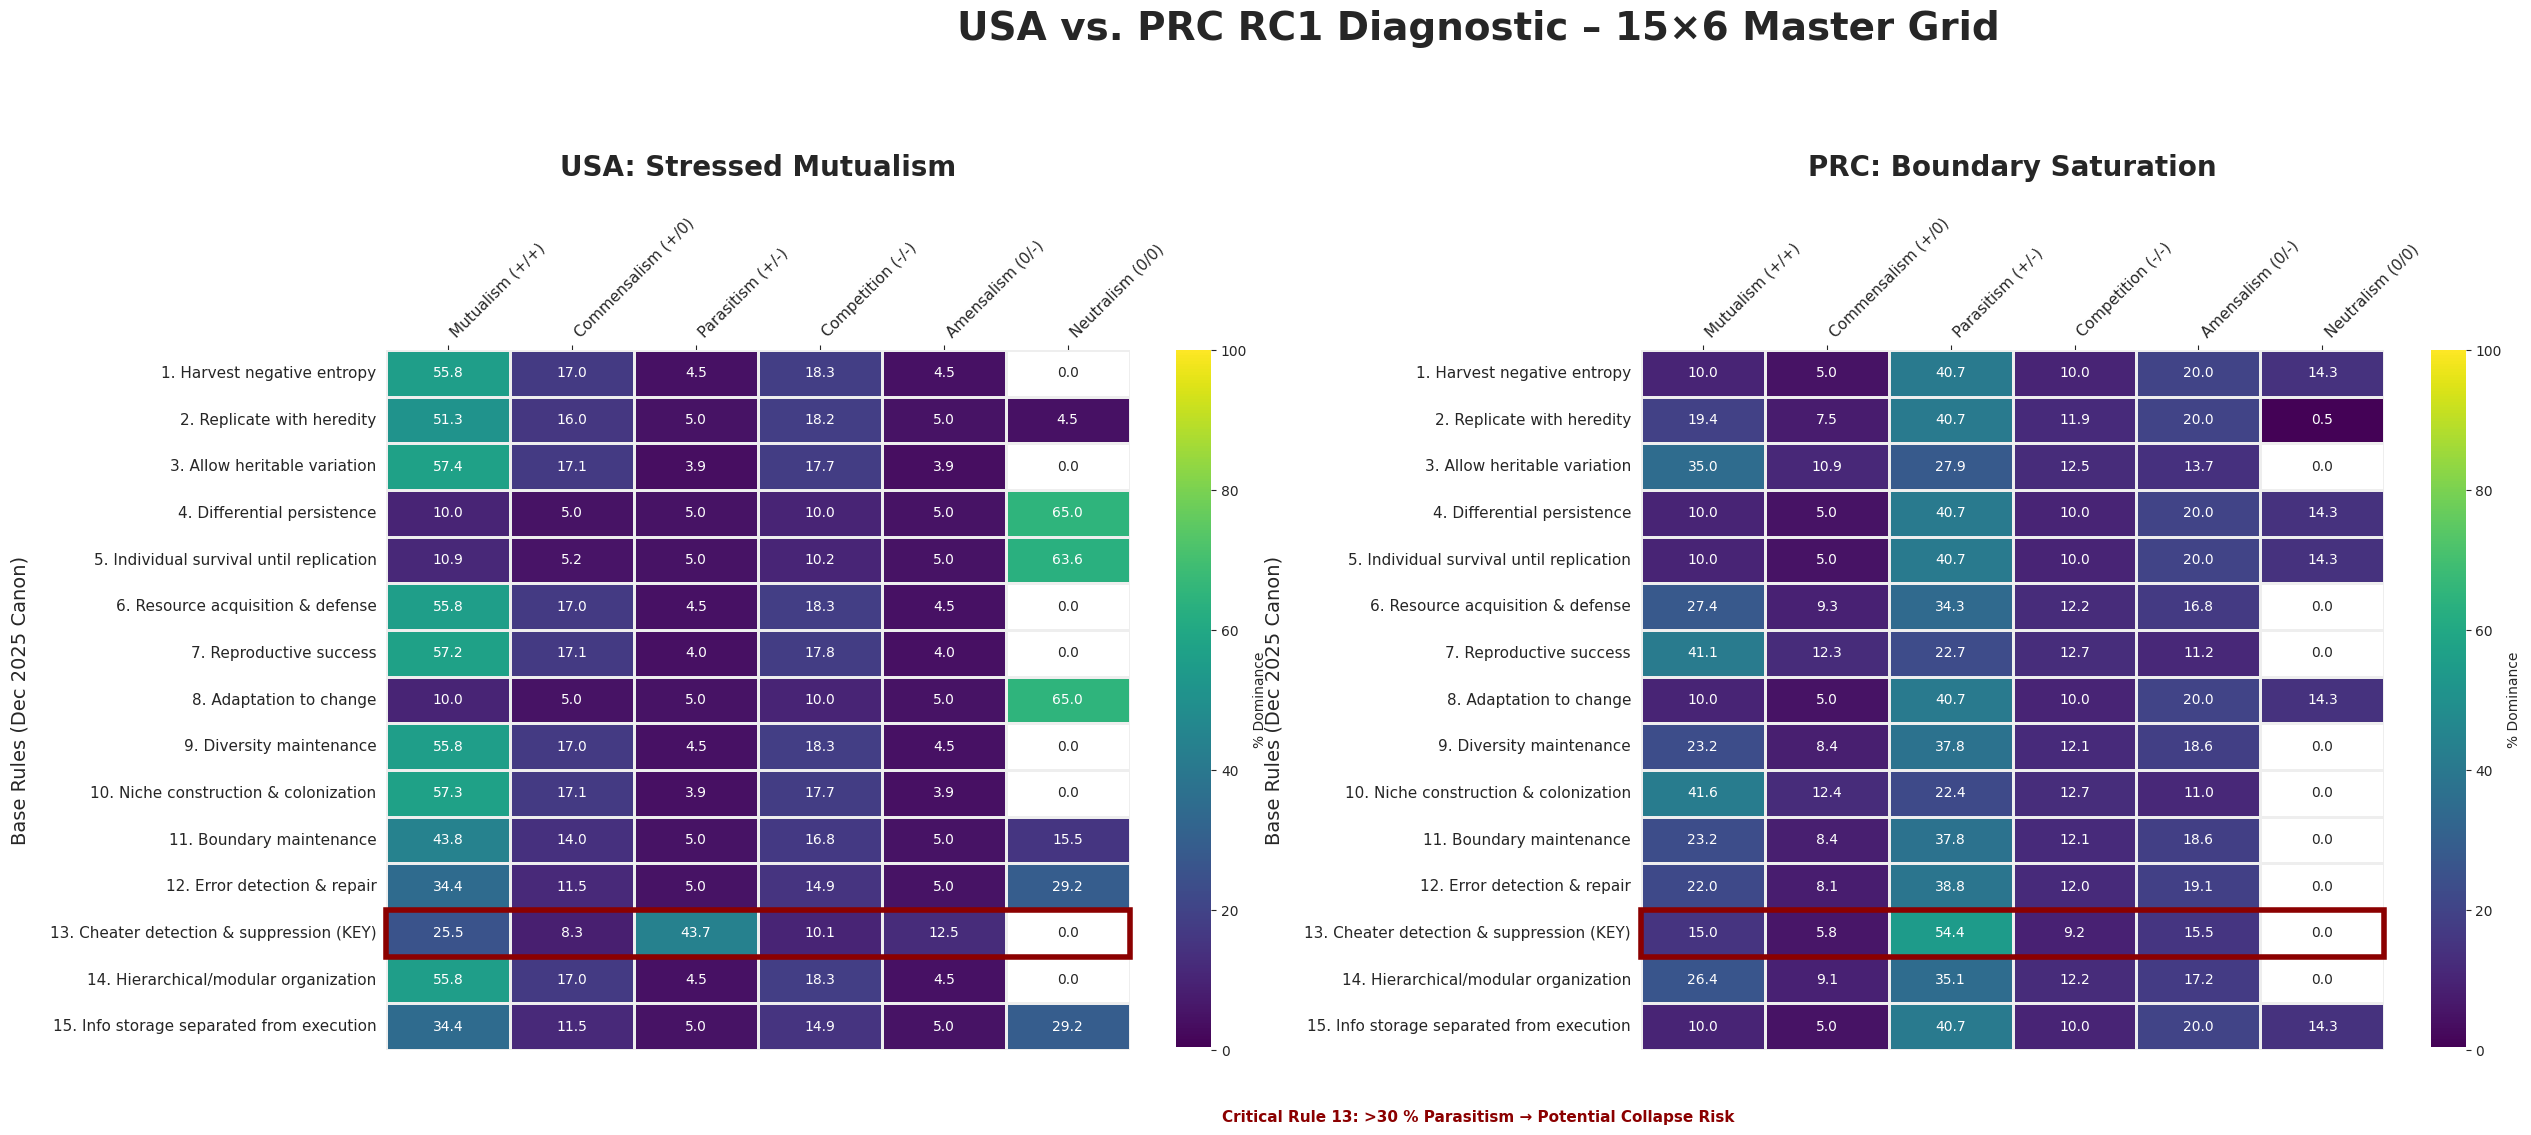

In [ ]:
# === PLOTTING: CONSOLIDATED FIXED VERSION ===

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Styling
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [1, 1, 1, 1]
custom_map = LinearSegmentedColormap.from_list('WhiteViridis', newcolors)

oxford_red = "#8B0000"
moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/-)",
         "Competition (-/-)", "Amensalism (0/-)", "Neutralism (0/0)"]

sns.set_style("whitegrid")

# CHANGE: sharey=False is required to independent control of tick visibility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 10), sharey=False)

# Heatmaps
for ax, df, title in zip([ax1, ax2], [usa_df, prc_df],
                         ["USA: Stressed Mutualism", "PRC: Boundary Saturation"]):

    sns.heatmap(df, annot=True, fmt=".1f", cmap=custom_map, vmin=0, vmax=100,
                linewidths=1, linecolor="#eeeeee",
                cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax)

    # X ticks on top, rotated
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_xticklabels(moves, rotation=45, ha="left", fontsize=11)

    # FIX: Explicitly set labels for BOTH axes
    ax.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=14, labelpad=15)

    # FIX: Force tick parameters to be visible on the right table
    ax.tick_params(axis='y', which='both', labelleft=True, labelsize=11)

    # Subtitle — lowered to avoid overlap with rotated moves
    ax.text(0.5, 1.28, title, transform=ax.transAxes,
            ha='center', va='top', fontsize=20, fontweight='bold')

    # Rule 13 highlight box
    ax.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False,
                               edgecolor=oxford_red, lw=4, clip_on=False))

# Main title — positioned high
fig.suptitle("USA vs. PRC RC1 Diagnostic – 15×6 Master Grid",
             fontsize=28, fontweight='bold', y=1.12)

# Critical note at bottom center
fig.text(0.5, 0.005, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=11, color=oxford_red, ha='center', va='bottom', fontweight='bold')

# Layout: generous top margin to prevent subtitle / move-label intersection
plt.subplots_adjust(top=0.78, bottom=0.08, wspace=0.35, left=0.08, right=0.92)

# Save & display
plt.savefig("usa_vs_prc_rc1_heatmap_labels_fixed_v3.png", dpi=300, bbox_inches="tight")
plt.show()